# **Graph Metrics (*Number of Edges*)**

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/algorithms4pepprotgraphs')
from algorithms4pepprotgraphs.module.notebook import NotebookApp
from algorithms4pepprotgraphs.util.plotting import boxplot, scatter

app = NotebookApp('.env.jupyter.AVPDiscover')
paths = app.paths()

[2025-03-26 05:29:42,668] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/Test/Test2/Log/Sequences_with_non_natural_amino_acids.csv
[2025-03-26 05:29:51,444] INFO [notebook.py:51] Setting:
dataset_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/StarPep/StarPep.csv
pdb_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/StarPep/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/Test/Test2
sequence_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/Test/2025-03-22T09.44.18-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/Test/2025-03-26T04.35.25-Graph_Analyzer


## 📊 **Data Analysis**

### **Data**

In [2]:
# data
data = pd.read_csv(app.graph_analysis['graph_metrics'])
data["distance_interval"] = data["distance_function"] + " " + data["interval"].astype(str)
data = data[["sequence", "distance_interval", "number_of_edges", "distance_function", "interval"]]

# statistics
statistics = pd.read_csv(
    app.graph_analysis['graph_metrics_summary'].with_name(
        app.graph_analysis['graph_metrics_summary'].name + "-number_of_connected_components.csv"
    )
)
statistics["distance_interval"] = statistics["distance_function"] + " " + statistics["interval"].astype(str)

data[["sequence", "distance_interval", "number_of_edges"]].head()

,sequence,distance_interval,number_of_edges
0,LQQLLFIAFRIGRRRRRRRR,"euclidean (0, 10)",98
1,LAQLLFIHFRIGRRRRRRRR,"euclidean (0, 10)",99
2,IIRILQQLLFIHFRIGRRRRRRRR,"euclidean (0, 10)",122
3,LQQLLFIHFAIGRRRRRRRR,"euclidean (0, 10)",97
4,LQQLLFIHFRAGRRRRRRRR,"euclidean (0, 10)",96


### **Distance Intervals**

In [ ]:
display(Markdown("\n".join(f"- {val}" for val in statistics["distance_interval"].unique())))

### **Analysis of Graph Number of Edges Distribution (*all distance intervals*)**

In [ ]:
# statistics
display(Markdown("<br>Statistics (*All Distance Intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics.reset_index(drop=True)[columns])

x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (all_distance_intervals) -histogram")

fig_size=(16, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Number of Edges (*All Distance Intervals*)"))
plt = boxplot(data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Number of Edges Distribution (*per Distance Percentile*)**

#### **25th percentile distance intervals**

In [ ]:
distance_intervals = [
    'euclidean (0, 10)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# statistics
display(Markdown("<br>Statistics (*25th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (p25_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Number of Edges (*25th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

#### **50th percentile distance intervals**

In [ ]:
distance_intervals = [
    'euclidean (0, 15)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

# statistics
display(Markdown("<br>Statistics (*50th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (p50_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Number of Edges (*50th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

#### **75th percentile distance intervals**

In [ ]:
distance_intervals = [
    'euclidean (0, 20)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'lance_williams (0, 0.4664)',
    'soergel (0, 0.6357)'  
]

# statistics
display(Markdown("<br>Statistics (*75th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (p75_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Number of Edges (*75th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Number of Edges Distribution (*per Distance Function*)**

#### **Euclidean**

In [ ]:
distance_function = 'euclidean'

# statistics
display(Markdown("<br>Statistics (*Euclidean*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (eu) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Euclidean*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Bhattacharyya**

In [ ]:
distance_function = 'bhattacharyya'

# statistics
display(Markdown("<br>Statistics (*Bhattacharyya*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (ba) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Bhattacharyya*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Canberra**

In [ ]:
distance_function = 'canberra'

# statistics
display(Markdown("<br>Statistics (*Canberra*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (ca) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Canberra*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Clark**

In [ ]:
distance_function = 'clark'

# statistics
display(Markdown("<br>Statistics (*Clark*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (cl) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Clark*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Angular Separation**

In [ ]:
distance_function = 'angular_separation'

# statistics
display(Markdown("<br>Statistics (*Angular Separation*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (as) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Angular Separation*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Lance Williams**

In [ ]:
distance_function = 'lance_williams'

# statistics
display(Markdown("<br>Statistics (*Lance Williams*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (lw) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Lance Williams*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Soergel**

In [ ]:
distance_function = 'soergel'

# statistics
display(Markdown("<br>Statistics (*Soergel*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'number_of_edges'
x_label = 'Distance Interval'
y_label = 'Number of Edges
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges (so) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Number of Edges (*Soergel*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Number of Edges vs Sequence Length Relationship (*per Distance Function*)**

#### **Euclidean**

<br>*Graph Number of Edges vs Sequence Length (*Euclidean*)*

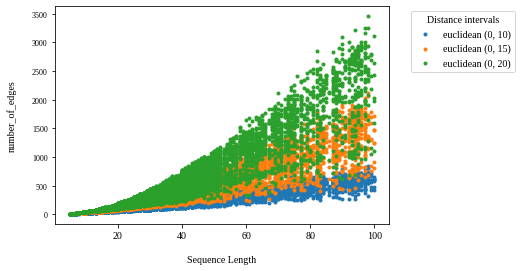

<br>*Graph Number of Edges vs Sequence Length - *Euclidean (0, 10)**

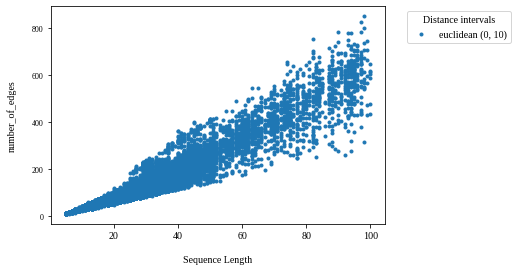

<br>*Graph Number of Edges vs Sequence Length - *Euclidean (0, 15)**

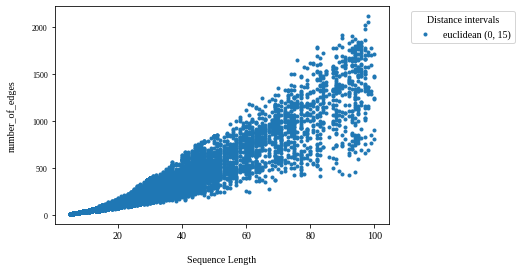

<br>*Graph Number of Edges vs Sequence Length - *Euclidean (0, 20)**

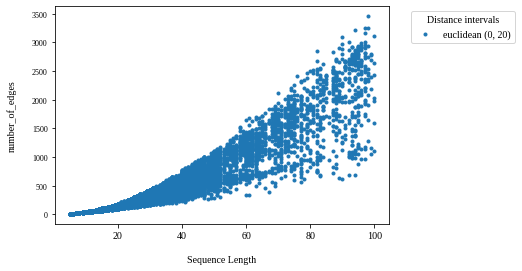

In [3]:
distance_function = 'euclidean'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Euclidean*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (eu) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 10)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Euclidean (0, 10)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (eu_0_10) -scatter")
columns = ['euclidean (0, 10)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 15)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Euclidean (0, 15)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (eu_0_15) -scatter")
columns = ['euclidean (0, 15)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 20)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Euclidean (0, 20)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (eu_0_20) -scatter")
columns = ['euclidean (0, 20)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Bhattacharyya**

In [ ]:
distance_function = 'bhattacharyya'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Bhattacharyya*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ba) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 1.5158)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 1.5158)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ba_0_1.5158) -scatter")
columns = ['bhattacharyya (0, 1.5158)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 2.4304)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 2.4304)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ba_0_2.4304) -scatter")
columns = ['bhattacharyya (0, 2.4304)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 3.6452)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Bhattacharyya (0, 3.6452)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ba_0_3.6452) -scatter")
columns = ['bhattacharyya (0, 3.6452)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Canberra**

In [ ]:
distance_function = 'canberra'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Canberra*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ca) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 1.5158)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 0.6155)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ca_0_0.6155) -scatter")
columns = ['canberra (0, 0.6155)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 2.4304)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 1.0142)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ca_0_1.0142) -scatter")
columns = ['canberra (0, 1.0142)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 3.6452)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Canberra (0, 1.4712)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (ca_0_1.4712) -scatter")
columns = ['canberra (0, 1.4712)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Clark**

In [ ]:
distance_function = 'clark'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Clark*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (cl) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 1.5158)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.4161)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (cl_0_0.4161) -scatter")
columns = ['clark (0, 0.4161)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 0.6813)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.6813)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (cl_0_0.6813) -scatter")
columns = ['clark (0, 0.6813)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 0.983)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Clark (0, 0.983)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (cl_0_0.983) -scatter")
columns = ['clark (0, 0.983)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Angular Separation**

In [ ]:
distance_function = 'angular_separation'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Angular Separation*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (as) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.018)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.018)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (as_0_0.018) -scatter")
columns = ['angular_separation (0, 0.018)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.0654)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.0654)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (as_0_0.0654) -scatter")
columns = ['angular_separation (0, 0.0654)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.1799)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Angular Separation (0, 0.1799)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (as_0_0.1799) -scatter")
columns = ['angular_separation (0, 0.1799)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Lance Williams**

In [ ]:
distance_function = 'lance_williams'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Lance Williams*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (lw) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.1789)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.1789)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (lw_0_0.1789) -scatter")
columns = ['lance_williams (0, 0.1789)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.0654)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.3041)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (lw_0_0.3041) -scatter")
columns = ['lance_williams (0, 0.3041)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.4664)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Lance Williams (0, 0.4664)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (lw_0_0.4664) -scatter")
columns = ['lance_williams (0, 0.4664)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Soergel**

In [ ]:
distance_function = 'soergel'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='number_of_edges',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Number of Edges'
x_label = 'Sequence Length'
y_label = 'Number of Edges
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Number of Edges vs Sequence Length (*Soergel*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (so) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.3035)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.3035)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (so_0_0.3035) -scatter")
columns = ['soergel (0, 0.3035)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.4664)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.4664)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (so_0_0.4664) -scatter")
columns = ['soergel (0, 0.4664)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.6357)
display(Markdown("<br>*Graph Number of Edges vs Sequence Length - *Soergel (0, 0.6357)**"))
output = paths['graph_metrics_path'].joinpath("Graph Number of Edges vs Sequence Length (so_0_0.6357) -scatter")
columns = ['soergel (0, 0.6357)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()